In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:

# Load CSVs
bam_svnn = pd.read_csv('bam_svnn_grid_results.csv')
no_bam_svnn = pd.read_csv('no_bam_svnn_grid_results.csv')
pca = pd.read_csv('pca_grid_results.csv')
naive = pd.read_csv('naive_grid_results.csv')
rand = pd.read_csv('rand_grid_results.csv')

# Add model column
bam_svnn['model'] = 'S-VNN with BAM'
no_bam_svnn['model'] = 'S-VNN without BAM'
pca['model'] = 'PCA'
naive['model'] = 'Naive'
rand['model'] = 'Random'

# Select columns
columns = ['model', 'seed', 'rmse', 'mean_diversity', 'mean_novelty', 'elapsed_sec']
all_data = pd.concat([bam_svnn[columns], no_bam_svnn[columns], pca[columns], naive[columns], rand[columns]], ignore_index=True)

# Compute mean per seed for models with multiple configurations
models_with_configs = ['S-VNN with BAM', 'S-VNN without BAM', 'Naive', 'Random']
mean_per_seed = all_data[all_data['model'].isin(models_with_configs)].groupby(['model', 'seed']).mean().reset_index()
pca_data = all_data[all_data['model'] == 'PCA']
mean_data = pd.concat([mean_per_seed, pca_data], ignore_index=True)

# Summary statistics
summary = mean_data.groupby('model').agg({
    'rmse': ['mean', sem],
    'mean_diversity': ['mean', sem],
    'mean_novelty': ['mean', sem],
    'elapsed_sec': ['mean', sem]
}).reset_index()
summary.columns = ['model', 'rmse_mean', 'rmse_se', 'diversity_mean', 'diversity_se', 'novelty_mean', 'novelty_se', 'elapsed_mean', 'elapsed_se']

# Detailed table for S-VNN configurations
bam_config = bam_svnn.groupby(['gso_type', 'sparsify']).agg({
    'rmse': ['mean', 'std'],
    'mean_diversity': ['mean', 'std'],
    'mean_novelty': ['mean', 'std']
}).reset_index()
bam_config.columns = ['gso_type', 'sparsify', 'rmse_mean', 'rmse_std', 'diversity_mean', 'diversity_std', 'novelty_mean', 'novelty_std']

no_bam_config = no_bam_svnn.groupby(['gso_type', 'sparsify']).agg({
    'rmse': ['mean', 'std'],
    'mean_diversity': ['mean', 'std'],
    'mean_novelty': ['mean', 'std']
}).reset_index()
no_bam_config.columns = ['gso_type', 'sparsify', 'rmse_mean', 'rmse_std', 'diversity_mean', 'diversity_std', 'novelty_mean', 'novelty_std']

# Print tables
print("Summary Table (Mean ± SE):")
print(summary.to_string(index=False))
print("\nS-VNN with BAM Configurations:")
print(bam_config.to_string(index=False))
print("\nS-VNN without BAM Configurations:")
print(no_bam_config.to_string(index=False))

Summary Table (Mean ± SE):
            model  rmse_mean  rmse_se  diversity_mean  diversity_se  novelty_mean  novelty_se  elapsed_mean  elapsed_se
            Naive   1.025762 0.004412        0.862740      0.002195      0.871789    0.005224      1.263117    0.031656
              PCA   0.930898 0.001029        0.869748      0.000434      0.938922    0.002120      1.208708    0.133713
           Random   1.216395 0.002432        0.866493      0.002345      0.891571    0.010600      1.178026    0.030466
   S-VNN with BAM   0.963118 0.000968        0.846356      0.001081      0.964532    0.002858     53.417372    0.152833
S-VNN without BAM   0.963157 0.000806        0.865223      0.001082      0.964521    0.002603      1.588470    0.021338

S-VNN with BAM Configurations:
gso_type sparsify  rmse_mean  rmse_std  diversity_mean  diversity_std  novelty_mean  novelty_std
     cov hard_thr   0.971945  0.003556        0.842614       0.009116      0.974287     0.006659
     cov soft_thr   0.97102

/tmp/ipykernel_9333/444851919.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


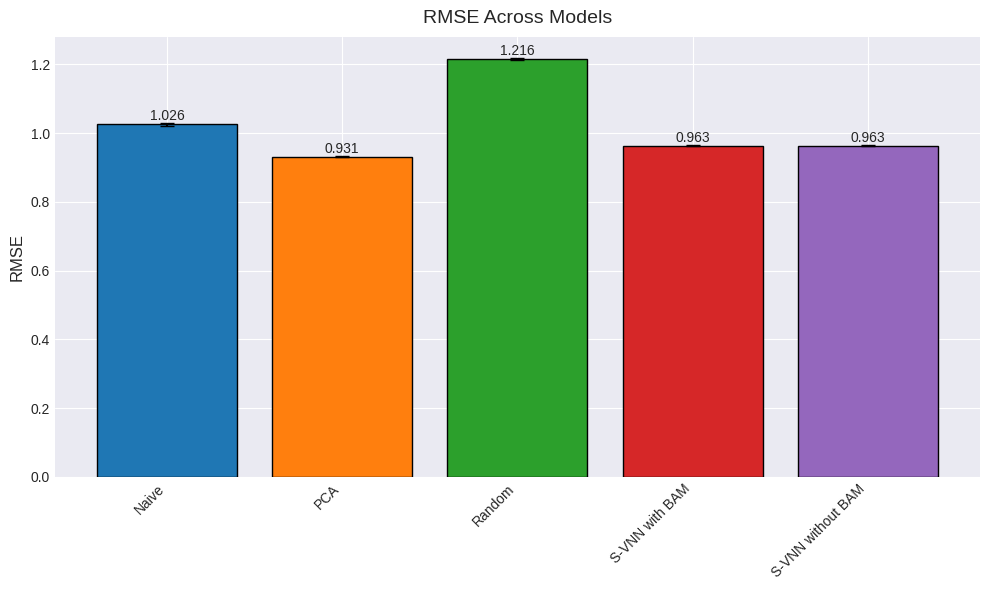

KeyError: 'mean_diversity_mean'

<Figure size 1000x600 with 0 Axes>

In [3]:

# Bar plots for each metric
plt.style.use('seaborn-darkgrid')
metrics = ['rmse', 'mean_diversity', 'mean_novelty']
titles = ['RMSE', 'Mean Diversity', 'Mean Novelty']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for metric, title in zip(metrics, titles):
    mean_col = f'{metric}_mean'
    se_col = f'{metric}_se'
    plt.figure(figsize=(10, 6))
    bars = plt.bar(summary['model'], summary[mean_col], yerr=summary[se_col], capsize=5, color=colors, edgecolor='black')
    plt.ylabel(title, fontsize=12)
    plt.title(f'{title} Across Models', fontsize=14, pad=10)
    plt.xticks(rotation=45, ha='right')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + summary[se_col].max()/2, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

# Scatter plot RMSE vs Novelty
plt.figure(figsize=(12, 8))
for i, model in enumerate(summary['model']):
    plt.errorbar(summary['rmse_mean'][i], summary['novelty_mean'][i],
                 xerr=summary['rmse_se'][i], yerr=summary['novelty_se'][i],
                 fmt='o', label=model, capsize=5, color=colors[i], markersize=10)
plt.xlabel('RMSE', fontsize=12)
plt.ylabel('Mean Novelty', fontsize=12)
plt.title('RMSE vs Mean Novelty Trade-off', fontsize=14)
plt.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:

# Scatter plot RMSE vs Diversity
plt.figure(figsize=(12, 8))
for i, model in enumerate(summary['model']):
    plt.errorbar(summary['rmse_mean'][i], summary['diversity_mean'][i],
                 xerr=summary['rmse_se'][i], yerr=summary['diversity_se'][i],
                 fmt='o', label=model, capsize=5, color=colors[i], markersize=10)
plt.xlabel('RMSE', fontsize=12)
plt.ylabel('Mean Diversity', fontsize=12)
plt.title('RMSE vs Mean Diversity Trade-off', fontsize=14)
plt.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:

# Interaction plots for S-VNN
for metric in metrics:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=bam_svnn, x='sparsify', y=metric, hue='gso_type', errorbar='se', palette='viridis')
    plt.title(f'{titles[metrics.index(metric)]} for S-VNN with BAM by GSO and Sparsify', fontsize=14)
    plt.ylabel(titles[metrics.index(metric)], fontsize=12)
    plt.xlabel('Sparsification Method', fontsize=12)
    plt.legend(title='GSO Type')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.barplot(data=no_bam_svnn, x='sparsify', y=metric, hue='gso_type', errorbar='se', palette='viridis')
    plt.title(f'{titles[metrics.index(metric)]} for S-VNN without BAM by GSO and Sparsify', fontsize=14)
    plt.ylabel(titles[metrics.index(metric)], fontsize=12)
    plt.xlabel('Sparsification Method', fontsize=12)
    plt.legend(title='GSO Type')
    plt.tight_layout()
    plt.show()

In [ ]:

# Statistical Tests
for metric in metrics:
    groups = [mean_data[mean_data['model'] == m][metric] for m in summary['model']]
    f_stat, p_val = f_oneway(*groups)
    print(f"\nANOVA for {metric}: F={f_stat:.2f}, p={p_val:.4f}")
    if p_val < 0.05:
        tukey = pairwise_tukeyhsd(mean_data[metric], mean_data['model'])
        print(tukey)

# Additional Table: Best Configurations
best_bam = bam_svnn.loc[bam_svnn.groupby('seed')['mean_novelty'].idxmax()]
best_no_bam = no_bam_svnn.loc[no_bam_svnn.groupby('seed')['mean_novelty'].idxmax()]
best_configs = pd.concat([best_bam, best_no_bam])[['model', 'seed', 'gso_type', 'sparsify', 'rmse', 'mean_diversity', 'mean_novelty']]
print("\nBest Configurations by Novelty per Seed:")
print(best_configs.to_string(index=False))